In [1]:
import numpy as np
import math
import torch
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def dB_to_lin(x):
    return 10**(x/10)

def lin_to_dB(x):
    assert x != 0, "X is zero"
    return 10*np.log10(x)

In [6]:
class Lorenz96SSM(object):
    """ 
    This class defines the state space model for the high-dimensional Lorenz-96 attractor (Lorenz96SSM). The high-dimensional
    attractor is simulated using Runge-Kutta method (RK45) which uses the dynamics function defined using
    `L96`. The driving noise is incorporated in the forcing function of the attractor for the process / state trajectory 
    instead of conventional additive process noise (as in LinearSSM / LorenzSSM).
    """
    def __init__(self, n_states, n_obs, delta, delta_d, F_mu=8, decimate=False, mu_w=None, H=None, method='RK45') -> None:
        
        self.n_states = n_states
        self.delta = delta
        self.delta_d = delta_d
        self.n_obs = n_obs
        self.decimate = decimate
        self.F_mu = F_mu
        if H is None:
            self.H = np.eye(self.n_obs)
        else:
            self.H = H
        self.mu_w = mu_w
        self.method = method
    
    def h_fn(self, x):
        """ 
        Linear measurement setup y = x + w
        """
        if len(x.shape) == 1:   
            y_ = self.H @ x
        elif len(x.shape) > 1:
            y_ = np.einsum('ij,nj->ni', self.H, x)
        return y_
    
    def setStateCov(self, sigma_e2=0.1):
        self.Ce = sigma_e2 * np.eye(self.n_states)

    def setMeasurementCov(self, sigma_w2=1.0):
        self.Cw = sigma_w2 * np.eye(self.n_obs)

    def generate_state_sequence(self, T_time, sigma_e2_dB):

        self.sigma_e2 = dB_to_lin(sigma_e2_dB)
        x0 = self.F_mu * np.ones(self.n_states)  # Initial state (equilibrium)
        x0[0] += self.delta  # Add small perturbation to the first variable
        sol = solve_ivp(L96, 
                        t_span=(0.0, T_time), 
                        y0=x0, 
                        args=(self.n_states, self.F_mu, self.sigma_e2,), 
                        method=self.method, 
                        t_eval=np.arange(0.0, T_time, self.delta), 
                        max_step=self.delta)
    
        x_lorenz = np.concatenate((sol.y.T, x0.reshape((1, -1))), axis=0)
        assert x_lorenz.shape[-1] == self.n_states, "Shape mismatch for generated state trajectory"
        
        T = x_lorenz.shape[0]
        x_lorenz = x_lorenz - np.mean(x_lorenz, axis=0)
        
        if self.decimate == True:
            K = self.delta_d // self.delta
            x_lorenz_d = x_lorenz[0:T:K,:]
        else:        
            x_lorenz_d = np.copy(x_lorenz)

        return x_lorenz_d
    
    def generate_measurement_sequence(self, T, x_lorenz, smnr_dB=10.0):
        
        #signal_p = ((self.h_fn(x_lorenz) - np.zeros_like(x_lorenz))**2).mean()
        signal_p = np.var(self.h_fn(x_lorenz))
        #print("Signal power: {:.3f}".format(signal_p))
        self.sigma_w2 = signal_p / dB_to_lin(smnr_dB)
        self.setMeasurementCov(sigma_w2=self.sigma_w2)
        w_k_arr = np.random.multivariate_normal(self.mu_w, self.Cw, size=(T,))
        y_lorenz = np.zeros((T, self.n_obs))
        
        #print("smnr: {}, signal power: {}, sigma_w: {}".format(smnr_dB, signal_p, self.sigma_w2))
        
        #print(self.H.shape, x_lorenz.shape, y_lorenz.shape)
        for t in range(0,T):
            y_lorenz[t] = self.h_fn(x_lorenz[t]) + w_k_arr[t]
        
        if self.decimate == True:
            K = self.delta_d // self.delta
            y_lorenz_d = y_lorenz[0:T:K,:] 
        else:
            y_lorenz_d = np.copy(y_lorenz)

        return y_lorenz_d
    
    def generate_single_sequence(self, T, sigma_e2_dB, smnr_dB):
        
        T_time = T * self.delta
        x_lorenz = self.generate_state_sequence(T_time=T_time, sigma_e2_dB=sigma_e2_dB)
        y_lorenz = self.generate_measurement_sequence(T=T, x_lorenz=x_lorenz, smnr_dB=smnr_dB)

        return x_lorenz, y_lorenz

In [7]:
def L96(t, x, N=20, F_mu=8, sigma_e2=.1):
    """Lorenz 96 model with constant forcing
    Adapted from: https://www.wikiwand.com/en/Lorenz_96_model 
    """
    # Setting up vector
    d = np.zeros(N)
    # Loops over indices (with operations and Python underflow indexing handling edge cases)
    F_N = np.random.normal(loc=F_mu, scale=np.sqrt(sigma_e2), size=(N,))
    for i in range(N):
        d[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F_N[i]
    return d


<Figure size 640x480 with 0 Axes>

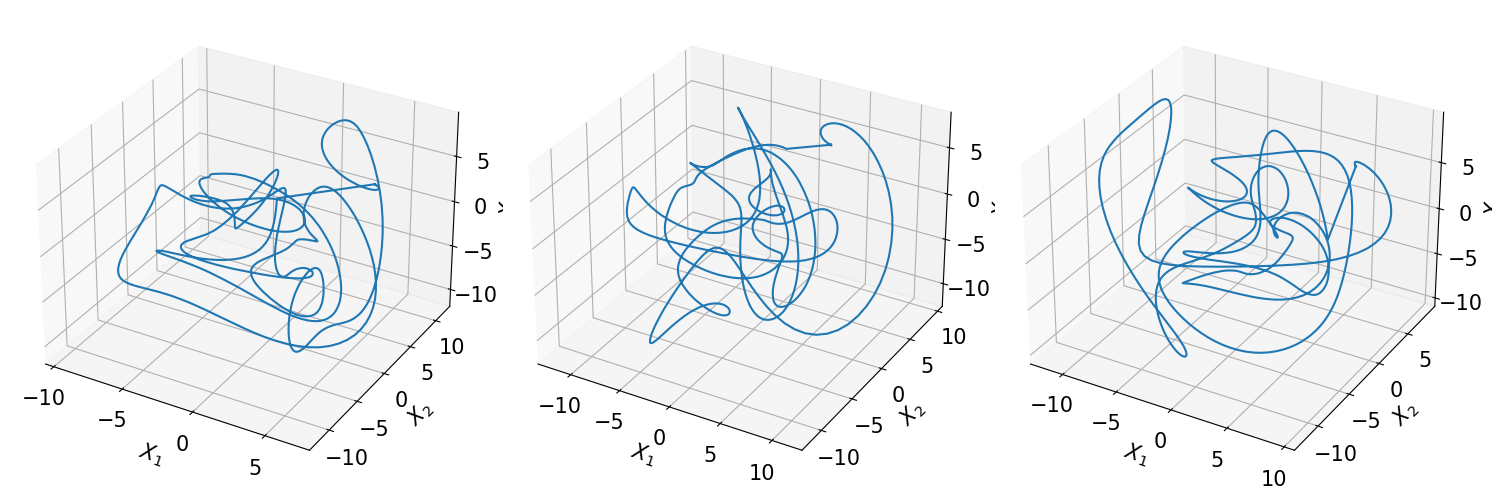

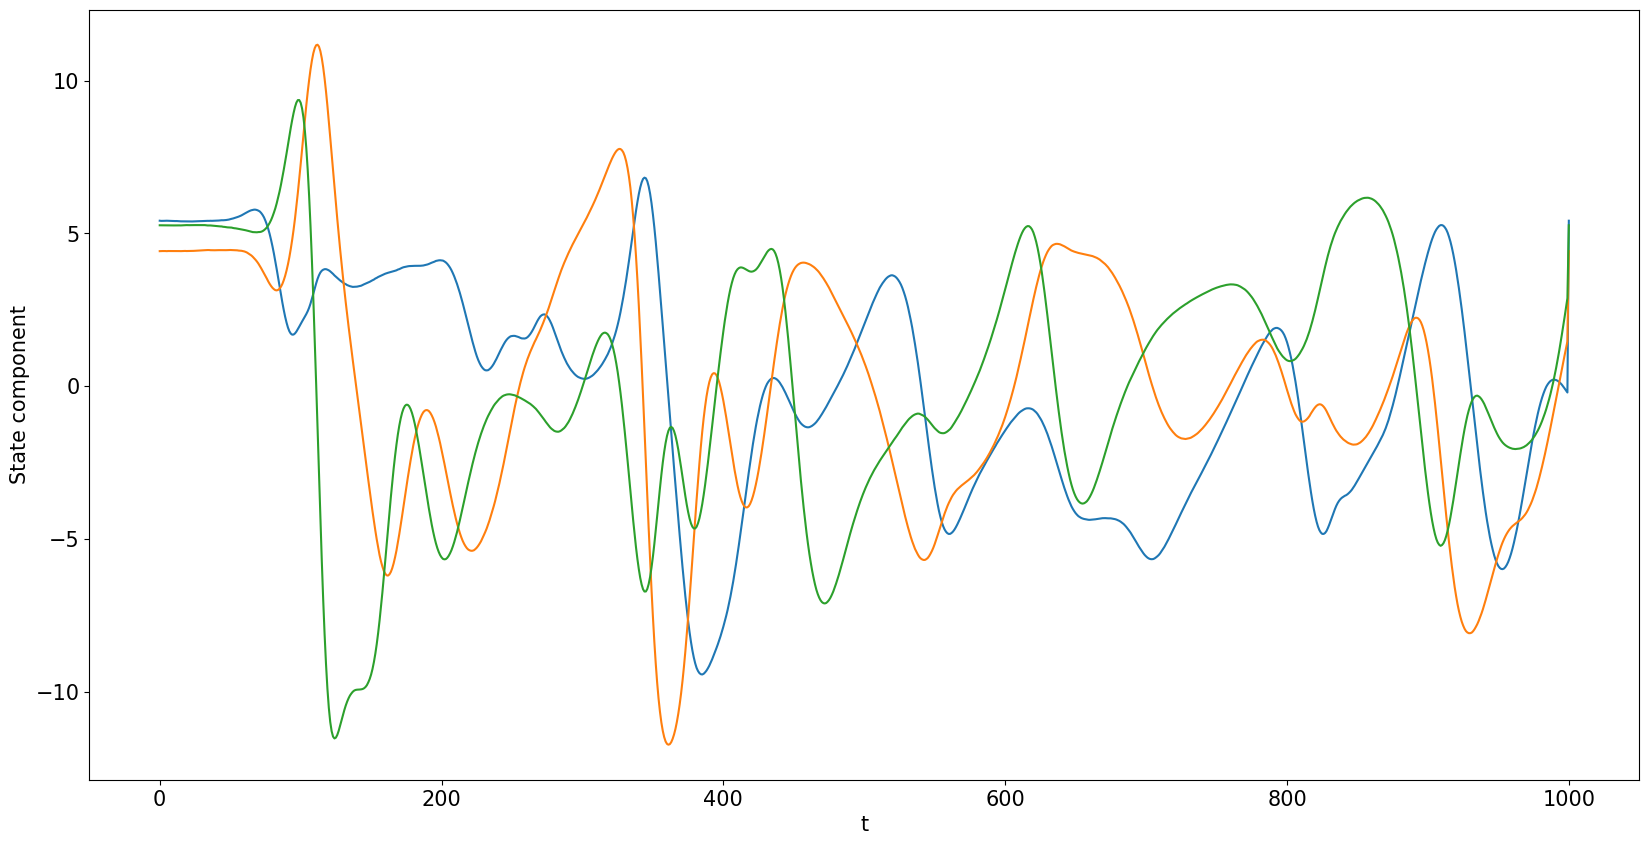

In [26]:
lorenz96model = Lorenz96SSM(
    n_states=20, 
    n_obs=20, 
    delta=0.01, 
    delta_d=0.01/2, 
    F_mu=8, 
    decimate=False, 
    mu_w=np.zeros((20,)), 
    H=None, 
    method='RK45'
)

x_true, y_true = lorenz96model.generate_single_sequence(
        T=1000, sigma_e2_dB=-10.0, smnr_dB=10.0
)

plt.figure()
l=0
fig = plt.figure(figsize=(15,10))
plt.rcParams['font.size'] = 15
ax = fig.add_subplot(131, projection='3d')
ax.plot(x_true[:,l], x_true[:,l+1], x_true[:,l+2])#, label=legend)
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$X_3$')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(x_true[:,l+1], x_true[:,int(l+2)], x_true[:,int(l+3)])#, label=legend)
ax2.set_xlabel('$X_1$')
ax2.set_ylabel('$X_2$')
ax2.set_zlabel('$X_3$')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(x_true[:,int(l+2)], x_true[:,int(l+3)], x_true[:,int(l+4)])#, label=legend)
ax3.set_xlabel('$X_1$')
ax3.set_ylabel('$X_2$')
ax3.set_zlabel('$X_3$')

plt.tight_layout()
plt.show()

# Plotting time-wise state trajectory evolution
plt.figure(figsize=(20, 10))
#plt.plot(x_true)
plt.plot(x_true[:,:3])
plt.xlabel('t')
plt.ylabel('State component')
plt.show()

Run: 1
[[ 5.00306156  5.14347323  4.56015347 ...  4.67500666  4.98077998
   5.36827493]
 [ 5.00023656  5.14453923  4.55975959 ...  4.67941688  4.98128462
   5.37305812]
 [ 4.9958851   5.13689494  4.56024737 ...  4.67869783  4.98283172
   5.37251478]
 ...
 [-7.31328918 -5.8213352  -4.96134043 ... -0.9419769   4.69851924
  -3.02443693]
 [-7.12498952 -5.66879174 -5.17992037 ... -0.88358552  4.68382734
  -3.44710898]
 [ 5.00306156  5.14347323  4.56015347 ...  4.67500666  4.98077998
   5.36827493]] [  0   5  10  15  20  25  30  35  40  45  51  56  61  66  71  76  81  86
  91  96 102 107 112 117 122 127 132 137 142 147 153 158 163 168 173 178
 183 188 193 199]
Run: 2
[[ 4.83352707  4.56470376  4.95274556 ...  4.93178809  5.62159742
   5.13451126]
 [ 4.83467586  4.5648674   4.95468206 ...  4.93615659  5.62178199
   5.13680399]
 [ 4.83411536  4.56301111  4.9495764  ...  4.94150448  5.61859596
   5.13952312]
 ...
 [-0.34544371  5.23676266 -6.06215235 ... -4.50994073 -4.71813813
  -5.07163363]
 

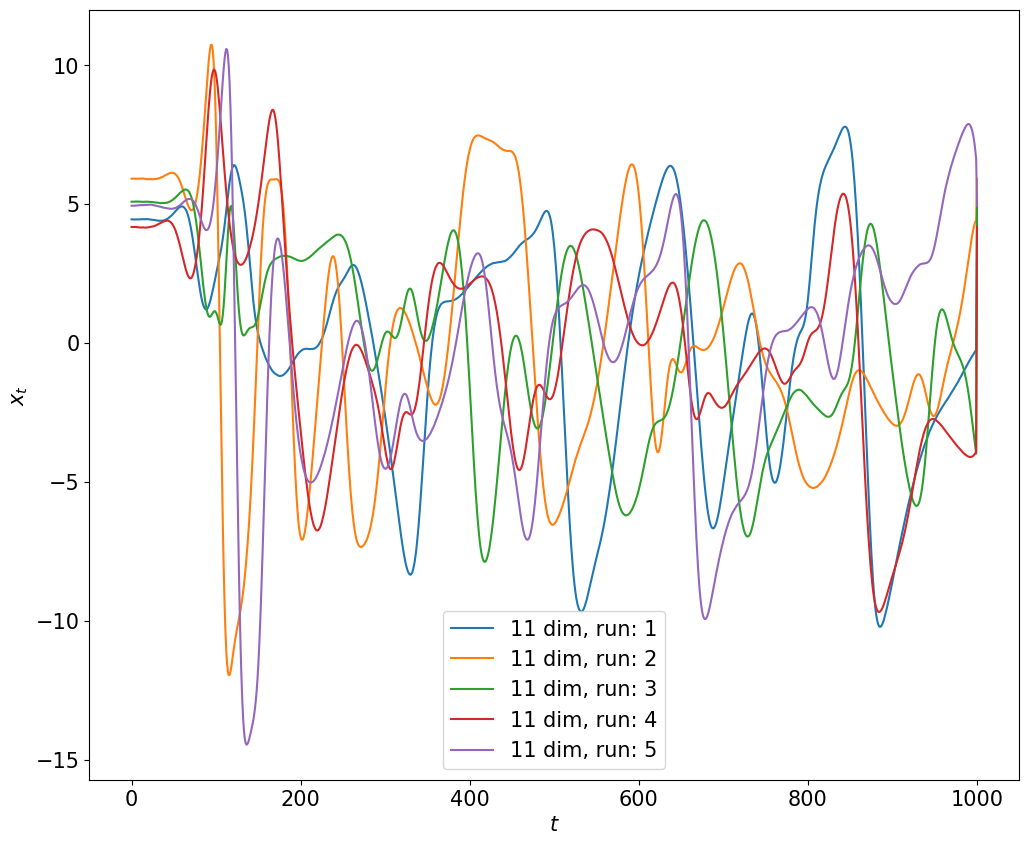

In [8]:
# Plot the first three variables

num_runs = 5
fig = plt.figure(figsize=(12,10))
x_true_all_runs = np.zeros((num_runs, x_true.shape[0], x_true.shape[1]))
K = 40 # decimation factor
for run in range(num_runs):
    print("Run: {}".format(run+1))
    x_true, y_true = lorenz96model.generate_single_sequence(
        T=1000, sigma_e2_dB=-10.0, smnr_dB=10.0
    )
    idx_reqd = np.linspace(0, x_true.shape[1]-1, K).astype(np.int16)
    print(x_true, idx_reqd)
    #fig = plt.figure(figsize=(12,10))
    #ax = fig.add_subplot()
    for i, id_ in enumerate(idx_reqd[2:3]):
        #print(i, id_)
        plt.plot(x_true[:, id_], label="{} dim, run: {}".format(id_+1, run+1))
        
    x_true_all_runs[run, :, :] = x_true
    
plt.ylabel("$x_{t}$")
plt.xlabel("$t$")
plt.legend()
plt.show()

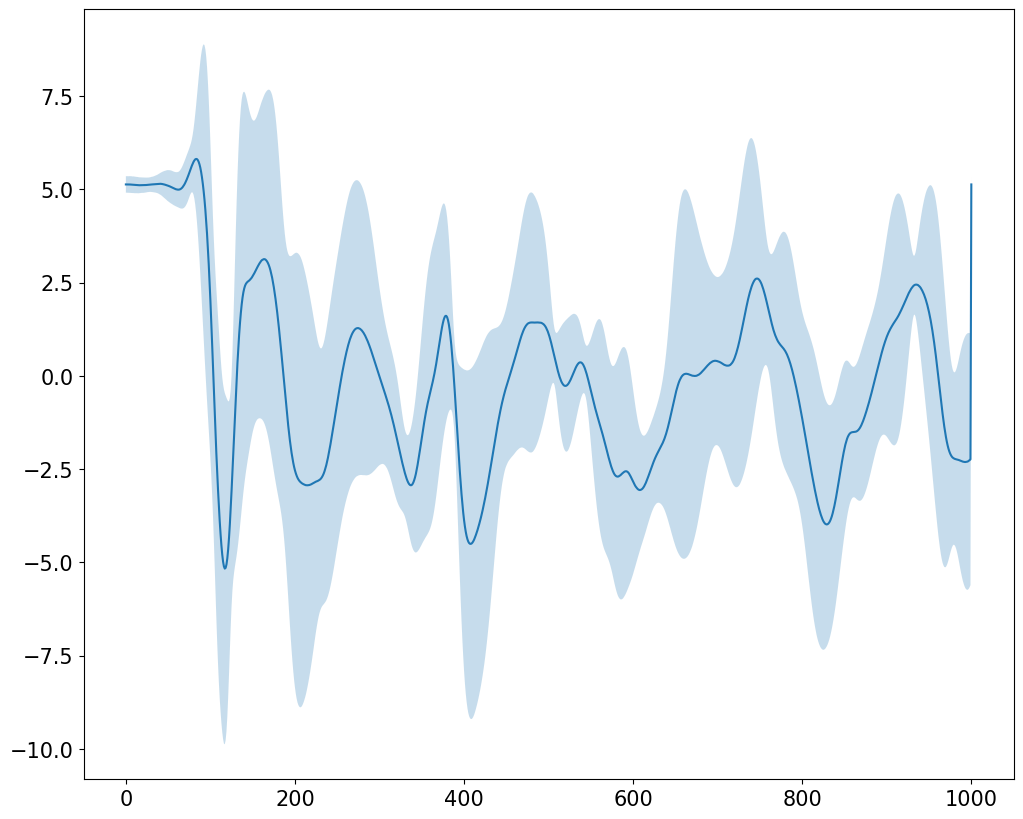

In [9]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot()
for i, id_ in enumerate(idx_reqd[:1]):
    #print(i, id_)
    plt.plot(np.mean(x_true_all_runs, axis=0)[:,id_])
    plt.fill_between(
                    np.arange(np.mean(x_true_all_runs, axis=0)[:,id_].shape[0]),
                    np.mean(x_true_all_runs, axis=0)[:,id_] + np.std(x_true_all_runs, axis=0)[:,id_],
                    np.mean(x_true_all_runs, axis=0)[:,id_] - np.std(x_true_all_runs, axis=0)[:,id_],
                    alpha=0.25
                    )
plt.show()

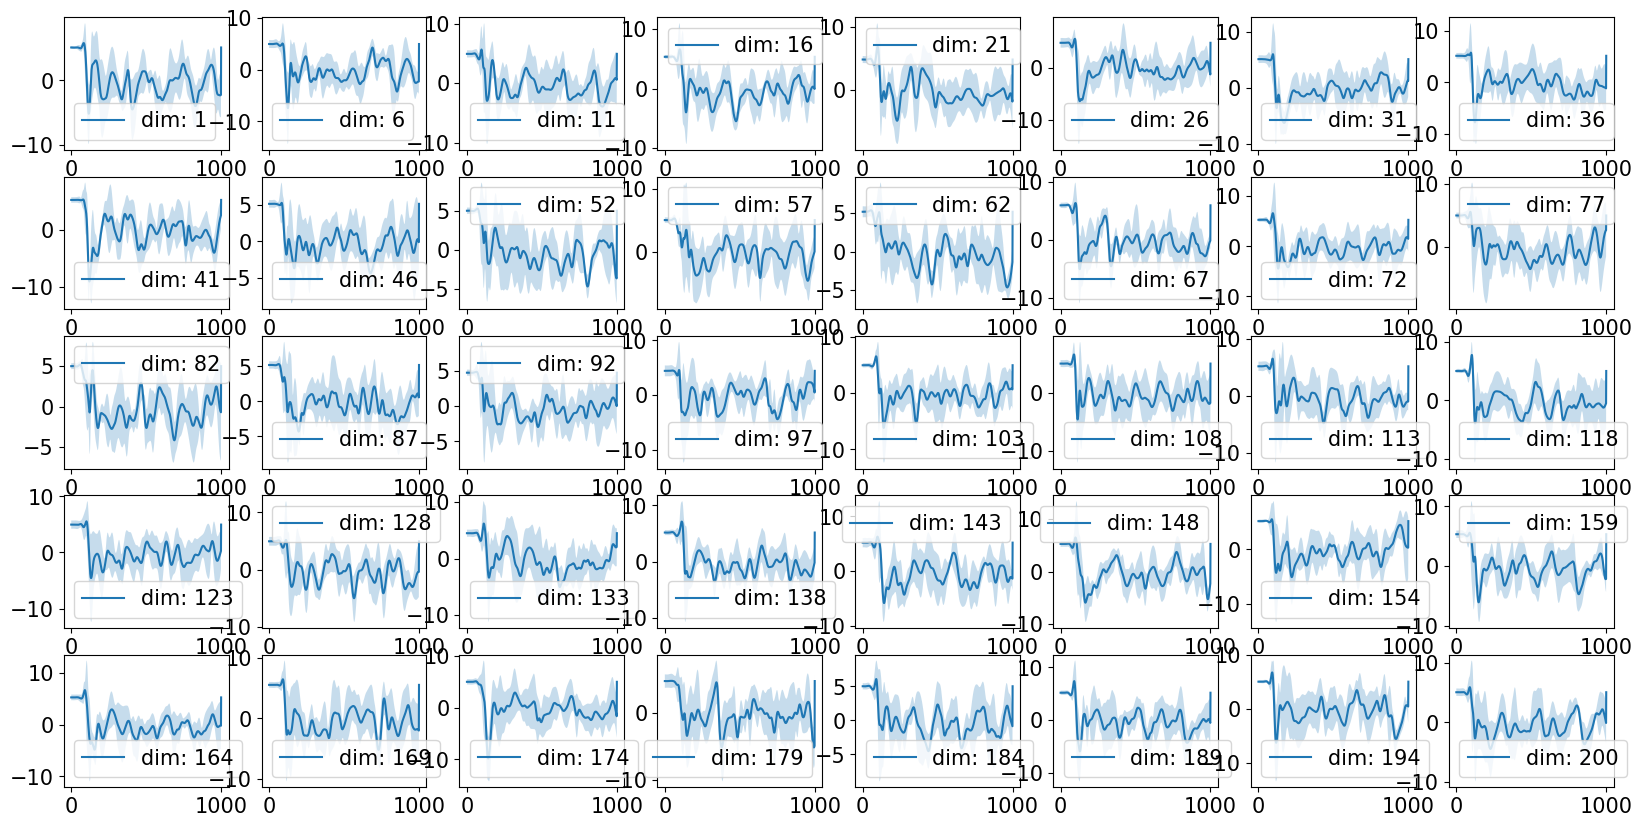

In [ ]:
fig = plt.figure(figsize=(30,20))
for i, id_ in enumerate(idx_reqd):
    #print(i, id_)
    plt.subplot(5,K//5,i+1)
    plt.plot(np.mean(x_true_all_runs, axis=0)[:,id_], label="dim: {}".format(id_+1))
    plt.fill_between(
                    np.arange(np.mean(x_true_all_runs, axis=0)[:,id_].shape[0]),
                    np.mean(x_true_all_runs, axis=0)[:,id_] + np.std(x_true_all_runs, axis=0)[:,id_],
                    np.mean(x_true_all_runs, axis=0)[:,id_] - np.std(x_true_all_runs, axis=0)[:,id_],
                    alpha=0.25
                    )
    plt.legend()
plt.show()